# Autenticação Hugging Face
Este notebook carrega um dataset privado do Hugging Face.
Se você receber erro de permissão, siga as instruções na célula de código abaixo para autenticar usando o token do Hugging Face.

In [17]:
from dotenv import load_dotenv
import os
from datasets import load_dataset

load_dotenv('.env')
token = os.environ.get('HF_TOKEN')
if not token:
    print('Variável HF_TOKEN não definida. Edite o arquivo .env e adicione seu token.')

ds = load_dataset("wmcnicho/StudyChat")
print(ds)

DatasetDict({
    train: Dataset({
        features: ['prompt', 'response', 'topic', 'messages', 'timestamp', 'chatId', 'userId', 'interactionCount', 'chatTitle', 'chatStartTime', 'chatTotalInteractionCount', 'llm_label', 'semester'],
        num_rows: 16851
    })
})


In [18]:
import pandas as pd

def to_turns(example):
    chatId = example.get("chatId")
    interaction_count = example.get("interactionCount", 0)
    prompt = example.get("prompt", "")
    response = example.get("response", "")
    rows = []
    raw_llm = example.get("llm_label") or {}
    if isinstance(raw_llm, dict):
        llm_label = (raw_llm.get("label") or "").strip()
    else:
        # caso raro: se vier string/None
        llm_label = str(raw_llm).strip() if raw_llm is not None else ""

    parts = [p.strip() for p in llm_label.split(">")] if llm_label else []

    #    "text": prompt + "Keywords: " + " ".join(parts),

    rows.append({
        "chatId": chatId,
        "type": "human",
        "text": prompt,
        "interaction_count": interaction_count,
    })
    rows.append({
        "chatId": chatId,
        "type": "ai",
        "text": response,
        "interaction_count": interaction_count,
        "llm_label_parts": parts, 
    })
    return rows

rows = []
for ex in ds["train"]:
    rows.extend(to_turns(ex))

df = pd.DataFrame(rows)
print(df.sample(5))

                                     chatId   type  \
3217   245139aa-43ed-4236-ab49-f822c5efb3e9     ai   
8044   8c40c02c-5a46-445f-868b-ce588efb811b  human   
2204   21719f9c-f578-4aa2-acac-572ed72c0cf7  human   
30535  999fb4af-2e1a-4e55-a80d-8873d01374b5     ai   
6419   d55601ed-3715-4c40-b9e1-61287c70c991     ai   

                                                    text  interaction_count  \
3217   Handling out of bounds errors for the tables i...                  0   
8044   is there a priority queue library in python i ...                 49   
2204   class Node:\n    #TODO\n    def __init__(self)...                  0   
30535  Indexing through the keys in a dictionary in P...                 11   
6419   The `KeyError` indicates that the column `'Tar...                  4   

                                    llm_label_parts  
3217       [contextual_questions, Code Explanation]  
8044                                            NaN  
2204                                  

In [ ]:
import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer
from pathlib import Path
from tqdm import tqdm

def generate_embeddings(df: pd.DataFrame) -> tuple[np.ndarray, pd.DataFrame]:
    """
    Generate normalized embeddings using SentenceTransformer.
    
    Args:
        df: DataFrame with 'text' column (and chatId, type, interaction_count)
        
    Returns:
        embeddings: numpy array of normalized embeddings
        df_meta: DataFrame with orig_index, text, chatId, type, interaction_count
    """
    # Detect device: mps > cuda > cpu
    if torch.backends.mps.is_available():
        device = "mps"
    elif torch.cuda.is_available():
        device = "cuda"
    else:
        device = "cpu"
    
    print(f"Using device: {device}")
    
    # Filter non-empty strings
    df_filtered = df[df["text"].notna() & (df["text"].str.strip() != "")].copy()
    df_filtered["orig_index"] = df_filtered.index
    df_filtered = df_filtered.reset_index(drop=True)
    
    print(f"Processing {len(df_filtered)} non-empty texts out of {len(df)} total...")
    
    # Load model
    model = SentenceTransformer("all-MiniLM-L6-v2", device=device)
    
    # Generate embeddings with progress bar
    texts = df_filtered["text"].tolist()
    embeddings = model.encode(
        texts,
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True,
        convert_to_numpy=True
    )
    
    # Create metadata DataFrame
    df_meta = df_filtered[["orig_index", "text", "chatId", "type", "interaction_count"]].copy()
    
    # Create artifacts directory
    artifacts_dir = Path("artifacts")
    artifacts_dir.mkdir(exist_ok=True)
    
    # Save embeddings and metadata
    np.save(artifacts_dir / "embeddings.npy", embeddings)
    df_meta.to_parquet(artifacts_dir / "embeddings_meta.parquet", index=False)
    
    print(f"✓ Embeddings shape: {embeddings.shape}")
    print(f"✓ Saved to: {artifacts_dir / 'embeddings.npy'}")
    print(f"✓ Metadata saved to: {artifacts_dir / 'embeddings_meta.parquet'}")
    
    return embeddings, df_meta


embeddings, df_meta = generate_embeddings(df)

Using device: mps
Processing 33701 non-empty texts out of 33702 total...


Batches:   0%|          | 1/527 [00:15<2:17:20, 15.67s/it]


KeyboardInterrupt: 

In [ ]:
from umap import UMAP

umap_model = UMAP(
    n_neighbors=15,
    n_components=10, 
    min_dist=0.1,
    random_state=42
)
X_umap = umap_model.fit_transform(embeddings)
print("UMAP shape:", X_umap.shape)

/opt/homebrew/Caskroom/miniconda/base/envs/studychat/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP shape: (16850, 10)


➡️ Varredura de K: 4..10 (N=16850, D=10)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


k= 4 | silhouette=0.4164 | DB=3.9649
k= 5 | silhouette=0.4070 | DB=3.7777
k= 6 | silhouette=0.3985 | DB=3.6665
k= 7 | silhouette=0.4110 | DB=3.8409
k= 8 | silhouette=0.4152 | DB=3.6803
k= 9 | silhouette=0.3863 | DB=4.0398
k=10 | silhouette=0.3611 | DB=4.0032
⏱️ Varredura concluída em 16.85s

⭐ k* = 4  | silhouette=0.4164 | DB=3.9649


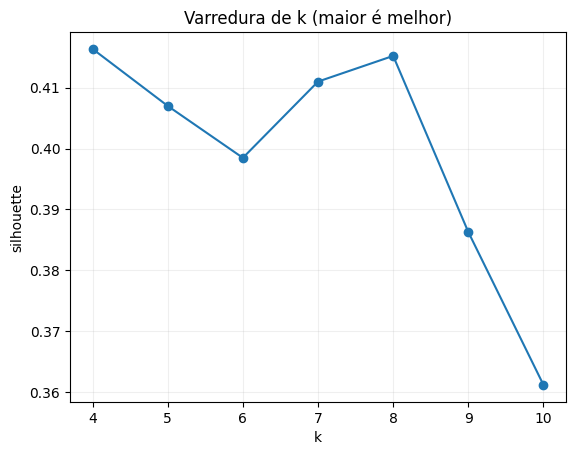

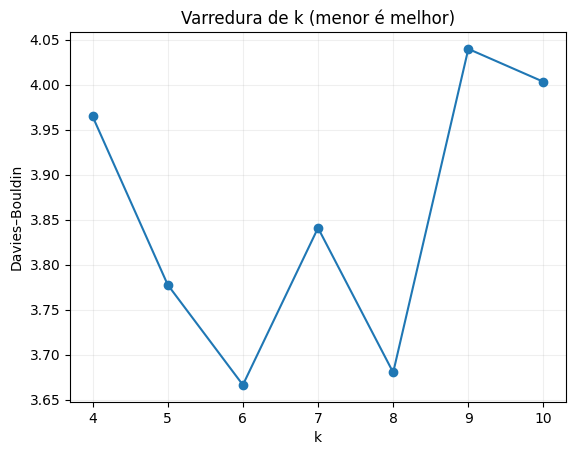

⏱️ Fit final em 0.01s

📊 Tamanho dos clusters:
cluster
0    2899
1    7043
2    3000
3    3908

✅ Artefatos salvos em 'artifacts':
 - kmeans_sweep.csv
 - kmeans_labels.parquet
 - kmeans_centroids.npy


,orig_index,text,chatId,type,interaction_count,cluster
11004,11005,"def create_frequency_tables(document, n):\n ...",181bf5b2-4f78-4d88-9403-b27aef32e19f,human,0,1
4730,4731,ValueError Trac...,901ba7f4-2ded-46ed-9856-12650af9ea92,human,1,0
16171,16172,so how did you implement this technique in my ...,8bb8a336-176a-4d6d-9e74-a380945fe328,human,15,1
4501,4502,tell me more about indexing pytorch tensors,1a8382a2-768d-4d00-a134-04b28c09a8b9,human,1,0
14453,14454,# Step 1: Calculate the percentage of rows con...,d003c95d-e29e-46a7-861a-a987e8c6ecbf,human,33,3


In [ ]:

import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# =========================
# Hiperparâmetros
# =========================
K_MIN = 150
K_MAX = 170
RANDOM_STATE = 42
ARTIFACTS_DIR = "artifacts"

# n_init compatível (scikit-learn>=1.4 aceita "auto")
try:
    _ = KMeans(n_clusters=2, n_init="auto", random_state=0)
    N_INIT = "auto"
except TypeError:
    N_INIT = 10

N, D = X_umap.shape
if N == 0:
    raise ValueError("`embeddings` está vazio.")
if K_MIN < 2:
    K_MIN = 2
if K_MAX < K_MIN:
    K_MAX = K_MIN


os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# =========================
# Varredura de K
# =========================
print(f"➡️ Varredura de K: {K_MIN}..{K_MAX} (N={N}, D={D})")
t0 = time.time()
sweep_rows = []
for k in range(K_MIN, K_MAX + 1):
    try:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT)
        labels = km.fit_predict(X_umap)
        # métricas (só fazem sentido se houver >1 cluster efetivo)
        if len(set(labels)) > 1:
            sil = silhouette_score(X_umap, labels)
            db = davies_bouldin_score(embeddings, labels)
        else:
            sil = np.nan
            db = np.nan
        sweep_rows.append({"k": k, "silhouette": sil, "davies_bouldin": db})
        print(f"k={k:>2} | silhouette={sil:.4f} | DB={db:.4f}")
    except Exception as e:
        warnings.warn(f"Falha em k={k}: {e}")
        sweep_rows.append({"k": k, "silhouette": np.nan, "davies_bouldin": np.nan})

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_csv(os.path.join(ARTIFACTS_DIR, "kmeans_sweep.csv"), index=False)
print(f"⏱️ Varredura concluída em {time.time()-t0:.2f}s")

# =========================
# Escolha do k*
# =========================
sweep_nonan = sweep_df.dropna(subset=["silhouette", "davies_bouldin"]).copy()
if sweep_nonan.empty:
    raise RuntimeError("Nenhum k produziu métricas válidas (silhouette/DB). Verifique embeddings/dados.")

sweep_nonan.sort_values(["silhouette", "davies_bouldin"], ascending=[False, True], inplace=True)
best = sweep_nonan.iloc[0].to_dict()
K_STAR = int(best["k"])
print(f"\n⭐ k* = {K_STAR}  | silhouette={best['silhouette']:.4f} | DB={best['davies_bouldin']:.4f}")

# =========================
# Plots das métricas
# =========================
plt.figure()
plt.plot(sweep_df["k"], sweep_df["silhouette"], marker="o")
plt.xlabel("k"); plt.ylabel("silhouette"); plt.title("Varredura de k (maior é melhor)")
plt.grid(True, alpha=0.2)
plt.show()

plt.figure()
plt.plot(sweep_df["k"], sweep_df["davies_bouldin"], marker="o")
plt.xlabel("k"); plt.ylabel("Davies–Bouldin"); plt.title("Varredura de k (menor é melhor)")
plt.grid(True, alpha=0.2)
plt.show()

# =========================
# Fit final com k*
# =========================
t1 = time.time()
kmeans_final = KMeans(n_clusters=K_STAR, random_state=RANDOM_STATE, n_init=N_INIT).fit(X_umap)
labels = kmeans_final.labels_
centroids = kmeans_final.cluster_centers_
print(f"⏱️ Fit final em {time.time()-t1:.2f}s")

# =========================
# Saídas + persistência
# =========================
df_clusters = df_meta.copy()
df_clusters["cluster"] = labels

# distribuição de tamanhos
counts = df_clusters["cluster"].value_counts().sort_index()
print("\n📊 Tamanho dos clusters:")
print(counts.to_string())

# salvar artefatos
df_clusters.to_parquet(os.path.join(ARTIFACTS_DIR, "kmeans_labels.parquet"), index=False)
np.save(os.path.join(ARTIFACTS_DIR, "kmeans_centroids.npy"), centroids)

print(f"\n✅ Artefatos salvos em '{ARTIFACTS_DIR}':")
print(" - kmeans_sweep.csv")
print(" - kmeans_labels.parquet")
print(" - kmeans_centroids.npy")

# Exibir um preview dos clusters
display(df_clusters.sample(min(5, len(df_clusters)), random_state=RANDOM_STATE))


In [ ]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,      # aumenta para menos clusters
    min_samples=5,            # menor → mais sensível a ruído
    metric='euclidean',       # ou 'cosine'
    cluster_selection_method='eom'
)

labels = clusterer.fit_predict(X_umap)

print("Clusters encontrados:", len(set(labels)) - (1 if -1 in labels else 0))
print("Proporção de ruído:", (labels == -1).mean())

/opt/homebrew/Caskroom/miniconda/base/envs/studychat/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/studychat/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using 

Clusters encontrados: 175
Proporção de ruído: 0.25513353115727005


In [ ]:
import pandas as pd
df_hdb = df_meta.copy()
df_hdb["cluster"] = labels

# Distribuição dos tamanhos
print(df_hdb["cluster"].value_counts().sort_index())

# Preview de exemplos por cluster
for c in df_hdb["cluster"].unique():
    if c == -1:
        continue
    print(f"\nCluster {c}")
    print(df_hdb[df_hdb["cluster"] == c]["text"].head(3).to_list())

cluster
-1      4299
 0        35
 1        55
 2       208
 3        89
        ... 
 170      57
 171     177
 172     123
 173      83
 174      40
Name: count, Length: 176, dtype: int64

Cluster 105
['rmse_poly = root_mean_squared_error(y_test_poly, y_pred_poly)\nmse_poly = rmse_poly ** 2\nr2_poly = r2_score(y_test_poly, y_pred_poly)\n\nexplain what this does', 'The R-squared score represents the proportion of the variance in the dependent variable (Size nm³) that is predictable from the independent variables (Temperature and Mols KCl). An R-squared score of 1 indicates perfect prediction, while a score of 0 indicates that the model does not explain any of the variability in the target variable\nexplain this', 'The R-squared score measures how well the independent variables explain the variability of the dependent variable.\n\nexplain this concisely']

Cluster 54
["Assignment 3: Equation of a Slime\nIn this assignment, we'll get our hands dirty with data and create our first ML mod

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

mask = labels != -1
sil = silhouette_score(X_umap[mask], labels[mask]) if mask.sum() > 1 else np.nan
db  = davies_bouldin_score(X_umap[mask], labels[mask]) if mask.sum() > 1 else np.nan

print(f"Silhouette (sem ruído): {sil:.4f}")
print(f"Davies–Bouldin (sem ruído): {db:.4f}")

Silhouette (sem ruído): 0.5957
Davies–Bouldin (sem ruído): 0.5621
